In [20]:
import pandas as pd
import numpy as np

# Read in the functional annotations file
df = pd.read_csv("/home/nanopore/projects/rna_seq_workflow/results/functional_annotations/20240716_FOXY/MOT_vs_OT_combined_annotations.csv")

# Filter out the rows that have no KEGG annotation
df = df[['KEGG_ko', 'log2FoldChange']]
df['KEGG_ko'] = df['KEGG_ko'].str.split(',')

# Explode the KEGG_ko column
df_exploded = df.explode('KEGG_ko')
df_exploded['KEGG_ko'] = df_exploded['KEGG_ko'].str.strip().str.replace('ko:', '')
df_exploded = df_exploded.replace('-', np.nan)
df_exploded = df_exploded.dropna()

# Filter the data based on the log2FoldChange values
filter_mask_high = (df_exploded["log2FoldChange"] > 2)
filter_mask_background = ((df_exploded["log2FoldChange"] < 1) & (df_exploded["log2FoldChange"] > -1))
filter_mask_low = (df_exploded["log2FoldChange"] < -2)

# Apply the filters
df_exploded_high = df_exploded[filter_mask_high]
df_exploded_background = df_exploded[filter_mask_background]
df_exploded_low = df_exploded[filter_mask_low]


In [21]:
import requests
from itertools import chain

# Function to fetch the pathways for a given KO
def fetch_pathways(ko):
    try:
        # Make a request to the KEGG API
        url = f"https://rest.kegg.jp/link/pathway/{ko}"
        response = requests.get(url)
        # Check if the response is successful
        if response.status_code == 200:
            if response.text.strip():
                pathways = []
                # Parse the response and extract the pathway IDs
                for line in response.text.splitlines():
                    pathway_list = line.split('\t')[1].strip().split(',')
                    ko_paths = [pathway for pathway in pathway_list if pathway.startswith('path:ko')]
                    # Append the pathway IDs to the list
                    if ko_paths:
                        pathways.append(ko_paths)
                # Flatten the list of pathways
                return list(chain.from_iterable(pathways))
            # If no pathways are found, return an empty list
            else:
                print("No pathways found for KO: ", ko)
                return []
        # If the response is not successful, print the error code    
        else:
            print("Error: ", response.status_code)
    # Handle exceptions
    except Exception as e:
        print(e)
    # Return an empty list if no pathways are found
    return []

# Apply the fetch_pathways function to the KEGG_ko column
df_exploded_high.loc[:, "Pathway_IDs"] = df_exploded_high["KEGG_ko"].apply(fetch_pathways)
df_exploded_background.loc[:, "Pathway_IDs"] = df_exploded_background["KEGG_ko"].apply(fetch_pathways)
df_exploded_low.loc[:, "Pathway_IDs"] = df_exploded_low["KEGG_ko"].apply(fetch_pathways)

df_exploded_high.head()



No pathways found for KO:  K09022
No pathways found for KO:  K16261
No pathways found for KO:  K14859
No pathways found for KO:  K13076
No pathways found for KO:  K13076
No pathways found for KO:  K15503
No pathways found for KO:  K15503
No pathways found for KO:  K13181
No pathways found for KO:  K14832
No pathways found for KO:  K14856
No pathways found for KO:  K14765
No pathways found for KO:  K17967
No pathways found for KO:  K20238
No pathways found for KO:  K14838
No pathways found for KO:  K14831
No pathways found for KO:  K14852
No pathways found for KO:  K14775
No pathways found for KO:  K14783
No pathways found for KO:  K14843
No pathways found for KO:  K14790
No pathways found for KO:  K17679
No pathways found for KO:  K14840
No pathways found for KO:  K18327
No pathways found for KO:  K14768
No pathways found for KO:  K07025
No pathways found for KO:  K07025
No pathways found for KO:  K14815
No pathways found for KO:  K07565
No pathways found for KO:  K14817
No pathways fo

/tmp/ipykernel_1116/1300803245.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_exploded_high.loc[:, "Pathway_IDs"] = df_exploded_high["KEGG_ko"].apply(fetch_pathways)


No pathways found for KO:  K14292
No pathways found for KO:  K16261
No pathways found for KO:  K16261
No pathways found for KO:  K16261
No pathways found for KO:  K18203
No pathways found for KO:  K17781
No pathways found for KO:  K09780
No pathways found for KO:  K01855
No pathways found for KO:  K17795
No pathways found for KO:  K01174
No pathways found for KO:  K13199
No pathways found for KO:  K13199
No pathways found for KO:  K15456
No pathways found for KO:  K11853
No pathways found for KO:  K11853
No pathways found for KO:  K11853
No pathways found for KO:  K11853
No pathways found for KO:  K11309
No pathways found for KO:  K22151
No pathways found for KO:  K17434
No pathways found for KO:  K20363
No pathways found for KO:  K03232
No pathways found for KO:  K02838
No pathways found for KO:  K20293
No pathways found for KO:  K06901
No pathways found for KO:  K06901
No pathways found for KO:  K06901
No pathways found for KO:  K06901
No pathways found for KO:  K06901
No pathways fo

/tmp/ipykernel_1116/1300803245.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_exploded_background.loc[:, "Pathway_IDs"] = df_exploded_background["KEGG_ko"].apply(fetch_pathways)


No pathways found for KO:  K00311
No pathways found for KO:  K01273
No pathways found for KO:  K20298
No pathways found for KO:  K20205
No pathways found for KO:  K20205
No pathways found for KO:  K11874
No pathways found for KO:  K16261
No pathways found for KO:  K16261
No pathways found for KO:  K08157
No pathways found for KO:  K19900


/tmp/ipykernel_1116/1300803245.py:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_exploded_low.loc[:, "Pathway_IDs"] = df_exploded_low["KEGG_ko"].apply(fetch_pathways)


,KEGG_ko,log2FoldChange,Pathway_IDs
2,K01824,8.526140,"[path:ko00100, path:ko01100, path:ko01110]"
6,K00559,7.758244,"[path:ko00100, path:ko01100, path:ko01110]"
9,K01739,6.952258,"[path:ko00270, path:ko00450, path:ko00920, pat..."
11,K00276,6.891625,"[path:ko00260, path:ko00350, path:ko00360, pat..."
16,K05917,6.388356,"[path:ko00100, path:ko01100, path:ko01110]"


In [22]:
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests


# Function to calculate the enrichment of pathways in a subset compared to a background
def calculate_enrichment(subset, background):
    # Calculate the total number of genes in the subset and background
    total_subset = len(subset)
    total_background = len(background)
    # Count the occurrences of each pathway in the subset and background
    subset_pathway_counts = subset.explode("Pathway_IDs")["Pathway_IDs"].value_counts()
    background_pathway_counts = background.explode("Pathway_IDs")["Pathway_IDs"].value_counts()
    enrichment = []
    # Iterate over the pathway IDs in the subset
    for pathway_id, count in subset_pathway_counts.items():
        # Get the count of the pathway in the background
        background_count = background_pathway_counts.get(pathway_id, 0)
        # Calculate the contingency table for the Fisher's exact test
        non_pathway_count = total_subset - count
        non_background_count = total_background - background_count
        contingency_table = [[count, background_count], [non_pathway_count, non_background_count]]
        # Perform the Fisher's exact test
        oddsratio, pvalue = fisher_exact(contingency_table)
        # Append the results to the enrichment list
        enrichment.append((pathway_id, count, background_count, oddsratio, pvalue))
    
    # Create a DataFrame from the enrichment list
    enrichment_df = pd.DataFrame(enrichment, columns=["Pathway_ID", "Count", "Background_Count", "Odds_Ratio", "P_Value"])
    
    # Perform multiple testing correction on the p-values
    enrichment_df["Adjusted_P_Value"] = multipletests(enrichment_df["P_Value"], method="fdr_bh")[1]
        
    return enrichment_df

# Calculate the enrichment of pathways in the high, low, and background subsets
high_enrichment = calculate_enrichment(df_exploded_high, df_exploded_background)
low_enrichment = calculate_enrichment(df_exploded_low, df_exploded_background)
    
high_enrichment.head()

,Pathway_ID,Count,Background_Count,Odds_Ratio,P_Value,Adjusted_P_Value
0,path:ko01100,41,212,0.574817,7.105663e-03,8.300755e-02
1,path:ko01110,19,125,0.477046,4.390122e-03,6.497381e-02
2,path:ko03008,16,3,21.253133,7.240247e-09,5.357783e-07
3,path:ko00100,8,9,3.303388,1.731163e-02,1.067550e-01
4,path:ko03010,8,10,2.967376,3.657200e-02,1.933092e-01


In [23]:
pathway_cache = {}

# Function to fetch the pathway names for a given pathway ID
def fetch_pathway_names(pathway_id):
    pathway_names = []
    # Check if the pathway ID is already in the cache
    if pathway_id in pathway_cache:
        pathway_names.append(pathway_cache[pathway_id])
    else:
        try:
            # Make a request to the KEGG API
            url = f"https://rest.kegg.jp/get/{pathway_id}"
            response = requests.get(url)
            # Check if the response is successful
            if response.status_code == 200:
                # Parse the response and extract the pathway name
                for line in response.text.splitlines():
                    # Extract the name of the pathway
                    if line.startswith("NAME"):
                        name = line.replace("NAME", "").strip()
                        pathway_cache[pathway_id] = name
                        pathway_names.append(name)
                        break
            # If the response is not successful, print the error code        
            else:
                print("Error: ", response.status_code)
        # Handle exceptions
        except Exception as e:
            print(e)
    # Return a semicolon-separated list of pathway names            
    return ";".join(set(pathway_names))

# Apply the fetch_pathway_names function to the Pathway_IDs column
high_enrichment.loc[:, "Pathway_Names"] = high_enrichment["Pathway_ID"].apply(fetch_pathway_names)
low_enrichment.loc[:, "Pathway_Names"] = low_enrichment["Pathway_ID"].apply(fetch_pathway_names)

high_enrichment.head()

,Pathway_ID,Count,Background_Count,Odds_Ratio,P_Value,Adjusted_P_Value,Pathway_Names
0,path:ko01100,41,212,0.574817,7.105663e-03,8.300755e-02,Metabolic pathways
1,path:ko01110,19,125,0.477046,4.390122e-03,6.497381e-02,Biosynthesis of secondary metabolites
2,path:ko03008,16,3,21.253133,7.240247e-09,5.357783e-07,Ribosome biogenesis in eukaryotes
3,path:ko00100,8,9,3.303388,1.731163e-02,1.067550e-01,Steroid biosynthesis
4,path:ko03010,8,10,2.967376,3.657200e-02,1.933092e-01,Ribosome


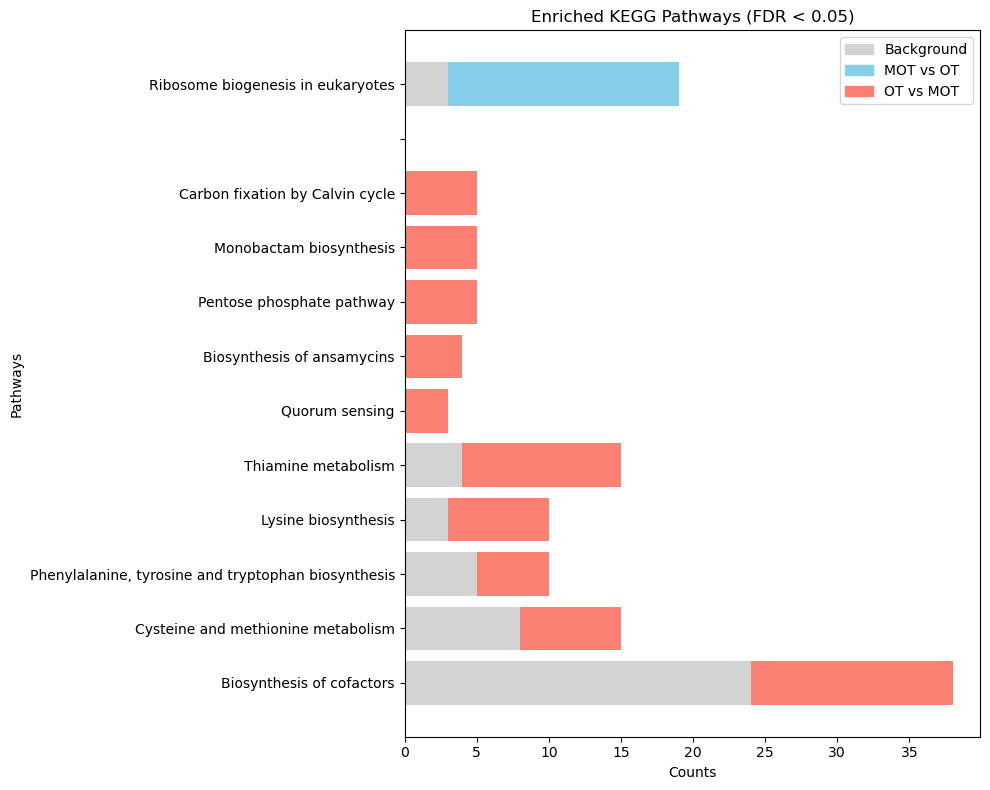

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd

def plot_stacked_bar_counts(high_enrichment, low_enrichment, top_n=10, title="Stacked Bar Plot: Ratio of Counts to Background Counts"):
    """
    Create a stacked horizontal bar plot to visualize the top enriched pathways 
    from high and low enrichment datasets, showing both pathway counts and background counts.
    The pathways are sorted by the ratio (Count / Background_Count) in descending order 
    within each group, with a visual separation between groups.

    Parameters:
        high_enrichment (pd.DataFrame): DataFrame with 'Pathway_Names', 'Count', 'Background_Count', and 'Adjusted_P_Value'.
        low_enrichment (pd.DataFrame): Similar DataFrame for the second group of enrichments.
        top_n (int): Number of top pathways to display for each group.
        title (str): Title for the plot.

    Returns:
        None
    """
    # Filter pathways with significant enrichment (FDR < 0.05)
    significant_high = high_enrichment[high_enrichment["Adjusted_P_Value"] < 0.01]
    significant_low = low_enrichment[low_enrichment["Adjusted_P_Value"] < 0.01]
    
    # Compute ratio and select top pathways based on the ratio (Count / Background_Count)
    top_high = (
        significant_high
        .assign(Ratio=significant_high["Count"] / significant_high["Background_Count"])
        .nlargest(top_n, "Ratio")
        .assign(Color="skyblue", Group="MOT vs OT")
    )
    top_low = (
        significant_low
        .assign(Ratio=significant_low["Count"] / significant_low["Background_Count"])
        .nlargest(top_n, "Ratio")
        .assign(Color="salmon", Group="OT vs MOT")
    )
    
    # Combine data into a single DataFrame but keep groups visually separated
    top_high = top_high.sort_values("Ratio", ascending=False)
    top_low = top_low.sort_values("Ratio", ascending=False)
    
    # Add a gap row for visual separation
    gap_row = pd.DataFrame({
        "Pathway_Names": [" "], 
        "Count": [0], 
        "Background_Count": [0], 
        "Color": "white", 
        "Group": "Gap", 
        "Ratio": [0]
    })
    
    combined_data = pd.concat([top_high, gap_row, top_low], ignore_index=True)
    
    # Prepare data for plotting
    pathway_names = combined_data["Pathway_Names"]
    counts = combined_data["Count"]
    background_counts = combined_data["Background_Count"]
    colors = combined_data["Color"]

    # Plot settings
    plt.figure(figsize=(10, 8))
    bar_positions = range(len(pathway_names))

    # Plot the background counts
    plt.barh(bar_positions, background_counts, color="lightgray", label="Background Count")

    # Overlay the counts for high and low enrichment
    for i, (count, bg_count, color) in enumerate(zip(counts, background_counts, colors)):
        plt.barh(i, count, color=color, left=bg_count)

    # Custom legend
    legend_patches = [
        mpatches.Patch(color="lightgray", label="Background"),
        mpatches.Patch(color="skyblue", label="MOT vs OT"),
        mpatches.Patch(color="salmon", label="OT vs MOT")
    ]
    plt.legend(handles=legend_patches, loc="best")

    # Add labels and formatting
    plt.yticks(bar_positions, pathway_names)
    plt.xlabel("Counts")
    plt.ylabel("Pathways")
    plt.title(title)
    plt.tight_layout()
    plt.gca().invert_yaxis()

    # Show the plot
    plt.show()

# Example call to the function
# plot_stacked_bar_counts(high_enrichment, low_enrichment, top_n=10, title="Enriched Pathways Sorted by Ratio (FDR < 0.05)")




# Call the function to plot
plot_stacked_bar_counts(high_enrichment, low_enrichment, top_n=10, title="Enriched KEGG Pathways (FDR < 0.01)")






In [27]:
significant_low = low_enrichment[low_enrichment["Adjusted_P_Value"] < 0.01]

significant_low

,Pathway_ID,Count,Background_Count,Odds_Ratio,P_Value,Adjusted_P_Value,Pathway_Names
0,path:ko01100,43,212,3.829911,3.326244e-06,5.404414e-05,Metabolic pathways
2,path:ko01230,23,46,6.581081,8.659534e-09,2.381372e-07,Biosynthesis of amino acids
4,path:ko01240,14,24,6.454710,3.930483e-06,5.404414e-05,Biosynthesis of cofactors
5,path:ko00730,11,4,29.688776,4.659944e-09,2.381372e-07,Thiamine metabolism
6,path:ko01210,11,26,4.377551,4.865117e-04,2.432559e-03,2-Oxocarboxylic acid metabolism
7,path:ko00260,7,12,5.734277,1.465084e-03,6.002825e-03,"Glycine, serine and threonine metabolism"
8,path:ko00300,7,3,23.333333,7.329161e-06,6.249362e-05,Lysine biosynthesis
9,path:ko00270,7,8,8.667453,2.602097e-04,1.431154e-03,Cysteine and methionine metabolism
11,path:ko00710,5,0,inf,9.089980e-06,6.249362e-05,Carbon fixation by Calvin cycle
12,path:ko00400,5,5,9.600000,1.527992e-03,6.002825e-03,"Phenylalanine, tyrosine and tryptophan biosynt..."
